# Anotaciones cuya especie no coincide con su carpeta

Las tablas de Raven de `data/raw/` viven en una carpeta por especie, pero la columna `Species`
se escribe a mano y en algunas filas trae otra especie. El protocolo de curación (RE1.1) las
resuelve con la carpeta; este cuaderno mira esas filas **antes** de cualquier limpieza para
distinguir dos causas:

- **error de tipeo**: la llamada es de la especie de la carpeta y sólo la columna está mal
  (`SN` por `SM`, `AC` en una tabla de `AS` con un tipo de llamada que sólo tiene `AS`);
- **copia entre carpetas**: la grabación y sus filas se copiaron desde la carpeta de la otra
  especie, o el analista anotó a propósito una llamada de otra especie que se oye en la grabación.

El equipo describe así su flujo de trabajo: al anotar, el audio se copia y pega en la carpeta de
cada especie que se oye en él, y en cada copia se anota esa especie. Con ese flujo, toda grabación
con filas de otra especie tendría que estar también en la carpeta de esa otra especie; el cuaderno
lo verifica (§3) y comprueba si el resto del corpus sigue ese flujo (§3.1).

Para cada fila discordante se comprueba (1) si el tipo de llamada pertenece al vocabulario de la
carpeta o al de la especie escrita, (2) si la misma grabación existe, byte a byte, en la carpeta
de la especie escrita y si allí está anotada la misma caja, y (3) si las filas discordantes son
un bloque contiguo de la tabla. Al final se dibuja cada evento junto a llamadas del mismo tipo de
las dos especies, para juzgarlo a ojo.

Lee sólo `data/raw/`. Ejecutar desde la raíz del repo o desde `notebooks/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile
import torch
import torchaudio
from matplotlib.axes import Axes
from matplotlib.patches import Rectangle

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from core.config import RAW_DIR, P  # noqa: E402
from data.annotations import (  # noqa: E402
    audio_signature,
    cleaned,
    list_files,
    recording_stem,
    species_of,
)
from data.species import BACKGROUND_SPECIES, CALL_TYPES, Species  # noqa: E402
from utils.audio import hz_to_y, mel_spectrogram, mel_to_db  # noqa: E402

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)
BOX = ["begin_time_s", "end_time_s", "low_freq_hz", "high_freq_hz"]
SPECIES_CODES = {s.name for s in Species if s.name.lower() not in BACKGROUND_SPECIES}
VOCABULARY = {s.name: set(codes) for s, codes in CALL_TYPES.items()}
# Dos cajas son "la misma" si sus bordes coinciden dentro de esta tolerancia.
SAME_BOX_S, SAME_BOX_HZ = 0.05, 50.0
print(ROOT)

/home/fcandia/tesis-primate


## 1. Tablas crudas, tal cual

Una fila por caja de Raven, con la especie de la carpeta al lado de lo que el analista escribió.
Sólo se normalizan los nombres de columna y se recortan espacios; ninguna otra regla.

In [2]:
def recording_of(table: Path) -> Path | None:
    for suffix in (".wav", ".WAV"):
        candidate = table.with_name(recording_stem(table) + suffix)
        if candidate.is_file():
            return candidate
    return None


def normalized(value: object, upper: bool) -> str:
    # Una celda vacía llega como NaN; cualquier otra cosa (texto, un número suelto) se conserva.
    missing = value is None or (isinstance(value, float) and np.isnan(value))
    text = "" if missing else str(value).strip()
    return text.upper() if upper else text.lower()


def read_raw(table: Path, audio: Path) -> pd.DataFrame:
    df = pd.read_csv(table, sep="\t")
    df.columns = [cleaned(column) for column in df.columns]
    df = df.reindex(columns=[*BOX, "species", "call_type"])
    df["folder"] = species_of(table).upper()
    df["written"] = df["species"].map(lambda v: normalized(v, upper=True))
    df["call"] = df["call_type"].map(lambda v: normalized(v, upper=False))
    df["table"] = str(table.relative_to(RAW_DIR))
    df["audio"] = str(audio)
    df["row"] = np.arange(len(df))
    return df


frames, unreadable = [], []
for table in list_files(RAW_DIR, ".txt"):
    if species_of(table) in BACKGROUND_SPECIES or (audio := recording_of(table)) is None:
        continue
    try:
        frames.append(read_raw(table, audio))
    except (pd.errors.ParserError, pd.errors.EmptyDataError, UnicodeDecodeError):
        unreadable.append(table)
raw = pd.concat(frames, ignore_index=True)
print(
    f"{len(raw)} filas en {raw['table'].nunique()} tablas con audio; {len(unreadable)} tablas ilegibles"
)
raw["written"].value_counts().rename("filas").to_frame().T

20082 filas en 2819 tablas con audio; 4 tablas ilegibles


written,LW,SM,AS,AC,SB,PT,AA,,CC,SN,},8,AN,-,AS---------------------AS,#,PTD,L
filas,4160,3672,3615,3100,2336,1176,1091,879,31,7,4,3,2,2,1,1,1,1


## 2. Filas discordantes

`written` es lo que dice la columna `Species`; `folder`, la carpeta. Se marcan las filas con
especie escrita distinta de la carpeta (una columna vacía no es discordante: el protocolo la
completa con la carpeta).

In [3]:
discordant = raw.loc[(raw["written"] != "") & (raw["written"] != raw["folder"])].copy()
discordant["valid_code"] = discordant["written"].isin(SPECIES_CODES)
discordant["call_in_folder"] = [
    c in VOCABULARY[f] for c, f in zip(discordant["call"], discordant["folder"], strict=True)
]
discordant["call_in_written"] = [
    (w in VOCABULARY) and (c in VOCABULARY[w])
    for c, w in zip(discordant["call"], discordant["written"], strict=True)
]
print(f"{len(discordant)} filas discordantes en {discordant['table'].nunique()} tablas")
summary = (
    discordant.groupby(["folder", "written", "call"])
    .agg(
        filas=("row", "size"),
        tablas=("table", "nunique"),
        en_vocab_carpeta=("call_in_folder", "first"),
        en_vocab_escrita=("call_in_written", "first"),
    )
    .reset_index()
)
summary

129 filas discordantes en 39 tablas


,folder,written,call,filas,tablas,en_vocab_carpeta,en_vocab_escrita
0,AA,AN,hc,1,1,False,False
1,AA,AN,hm,1,1,True,False
2,AA,LW,gc,1,1,True,False
3,AA,},gc,1,1,True,False
4,AC,AS,bc,34,3,True,True
5,AC,AS,chc,6,1,True,False
6,AC,SM,cc,6,1,True,True
7,AC,SM,chc,1,1,True,False
8,AS,AC,bc,14,1,True,True
9,AS,AC,hc,23,9,True,False


Lectura de la tabla: si el tipo de llamada existe sólo en el vocabulario de la carpeta, la
especie escrita es un error de tipeo casi seguro; si existe sólo en el de la especie escrita, la
fila describe una llamada de la otra especie; si existe en ambos, no se decide por vocabulario y
hay que mirar la grabación.

## 3. ¿La grabación está copiada en la carpeta de la especie escrita?

Es la verificación del flujo que describe el equipo. Se busca la grabación de cada fila
discordante en **todo** `data/raw/` (subcarpetas como `E and lower` incluidas) de dos maneras:

- **misma grabación**: cualquier `.wav` con el mismo tamaño y el mismo MD5 del primer MiB (la
  firma de RE1.1), se llame como se llame;
- **mismo nombre**: cualquier `.wav` con el mismo nombre aunque los bytes difieran (una copia
  reexportada o recortada).

Si hay copia en la carpeta de la especie escrita, se lee su tabla (si la tiene) y se busca allí
la misma caja.

In [4]:
all_wavs = [
    wav
    for wav in list_files(RAW_DIR, ".wav") + list_files(RAW_DIR, ".WAV")
    if species_of(wav) not in BACKGROUND_SPECIES
]
signature_of = {str(wav): audio_signature(wav) for wav in all_wavs}
by_name: dict[str, list[Path]] = {}
by_signature: dict[tuple[int, str], list[Path]] = {}
for wav in all_wavs:
    by_name.setdefault(wav.name.lower(), []).append(wav)
    by_signature.setdefault(signature_of[str(wav)], []).append(wav)
tables_by_audio = {row["audio"]: row["table"] for _, row in raw.drop_duplicates("audio").iterrows()}


def folders_holding(paths: list[Path], audio: Path) -> str:
    return ", ".join(sorted({species_of(p).upper() for p in paths if p != audio}))


def same_box_in(frame: pd.DataFrame, box: pd.Series) -> pd.DataFrame:
    close = (
        (frame["begin_time_s"] - box["begin_time_s"]).abs().le(SAME_BOX_S)
        & (frame["end_time_s"] - box["end_time_s"]).abs().le(SAME_BOX_S)
        & (frame["low_freq_hz"] - box["low_freq_hz"]).abs().le(SAME_BOX_HZ)
        & (frame["high_freq_hz"] - box["high_freq_hz"]).abs().le(SAME_BOX_HZ)
    )
    return frame.loc[close]


def copy_check(box: pd.Series) -> dict[str, object]:
    audio = Path(box["audio"])
    twins = by_signature[signature_of[str(audio)]]
    copies = [p for p in twins if p != audio and species_of(p).upper() == box["written"]]
    copy = copies[0] if copies else None
    matches = (
        same_box_in(raw.loc[raw["audio"] == str(copy)], box) if copy is not None else raw.iloc[:0]
    )
    return {
        "same_bytes_in": folders_holding(twins, audio),
        "same_name_in": folders_holding(by_name[audio.name.lower()], audio),
        "copy_in_written_folder": copy is not None,
        "copy_has_table": copy is not None and str(copy) in tables_by_audio,
        "same_box_in_copy": len(matches) > 0,
        "species_in_copy": ", ".join(sorted(set(matches["written"]))),
    }


checks = pd.DataFrame([copy_check(box) for _, box in discordant.iterrows()], index=discordant.index)
discordant[checks.columns] = checks
workflow = (
    discordant.groupby("table")
    .agg(
        carpeta=("folder", "first"),
        escrito=("written", lambda s: ", ".join(sorted(set(s)))),
        discordantes=("row", "size"),
        misma_grabacion_en=("same_bytes_in", "first"),
        mismo_nombre_en=("same_name_in", "first"),
        copia_en_escrita=("copy_in_written_folder", "any"),
        copia_con_tabla=("copy_has_table", "any"),
        misma_caja_alla=("same_box_in_copy", "any"),
    )
    .sort_values(["copia_en_escrita", "carpeta"], ascending=[False, True])
)
print(
    f"{int(workflow['copia_en_escrita'].sum())} de {len(workflow)} tablas "
    f"({int(discordant['copy_in_written_folder'].sum())} de {len(discordant)} filas) tienen la "
    "grabación copiada en la carpeta de la especie escrita\n"
    f"{int((workflow['misma_grabacion_en'] == '').sum())} tablas sin copia en ninguna otra carpeta; "
    f"{int((workflow['mismo_nombre_en'] != workflow['misma_grabacion_en']).sum())} con un .wav "
    "del mismo nombre pero distintos bytes en otra carpeta"
)
workflow

5 de 39 tablas (18 de 129 filas) tienen la grabación copiada en la carpeta de la especie escrita
33 tablas sin copia en ninguna otra carpeta; 0 con un .wav del mismo nombre pero distintos bytes en otra carpeta


,carpeta,escrito,discordantes,misma_grabacion_en,mismo_nombre_en,copia_en_escrita,copia_con_tabla,misma_caja_alla
table,,,,,,,,
peruvian_spider_monkey__AC/20241106_083703.txt,AC,SM,6,SM,SM,True,True,True
peruvian_spider_monkey__AC/20241106_083856.txt,AC,SM,1,SM,SM,True,False,False
bolivian_squirrel_monkey__SB/20240202_162050.txt,SB,SM,7,SM,SM,True,True,False
bolivian_squirrel_monkey__SB/20240601_063509.txt,SB,SM,3,SM,SM,True,True,False
bolivian_squirrel_monkey__SB/20240618_065834.txt,SB,SM,1,"PT, SM","PT, SM",True,True,False
night_monkey__AA/20240117_051057.txt,AA,LW,1,,,False,False,False
night_monkey__AA/20240410_052725.txt,AA,AN,1,,,False,False,False
night_monkey__AA/20240410_052750.txt,AA,AN,1,,,False,False,False
night_monkey__AA/20240608_192212.txt,AA,},1,,,False,False,False


Lectura: el flujo se cumple en **5 de las 39 tablas (18 de 129 filas)**, todas con `SM` como
especie escrita:

- `AC/20241106_083703`: la copia en `SM` tiene tabla y las 6 cajas `SM/cc` están idénticas allí:
  filas pegadas desde la tabla de `SM`;
- `AC/20241106_083856`: la copia está en `SM/E and lower`, sin tabla;
- las 3 de `SB` (`20240202_162050`, `20240601_063509`, `20240618_065834`): la copia en `SM` tiene
  tabla, pero anota cajas `SM/cc` distintas; las filas `SM/ppc` de `SB` no vienen de allí (`ppc`
  sólo existe en el vocabulario de `SB`).

Las otras **34 tablas (111 filas)** no tienen la grabación en la carpeta de la especie escrita:
33 no están en ninguna otra carpeta de `data/raw/`, ni con el mismo nombre ni con los mismos
bytes, y `PT/20240618_065757` sí está copiada en `SM`, pero lo escrito es `PTD`. En esas 34 el
analista escribió la otra especie sin copiar el audio, así que la carpeta de la especie escrita no
aporta nada para decidirlas; entre ellas están las 9 tablas escritas enteras con otra especie
(`AC/20240419_060128`, `AS/20240823_142122`, `AC/20240812_081914`, …).

### 3.1. ¿El resto del corpus sigue ese flujo?

Para saber si el flujo «copiar el audio a cada carpeta y anotar allí su especie» es la norma, se
toman todas las grabaciones de primates que están, byte a byte, en dos o más carpetas de especie,
y se mira si cada copia tiene tabla y si cada tabla anota sólo la especie de su carpeta.

In [5]:
written_by_audio: dict[str, set[str]] = {
    str(audio): set(group) - {""} for audio, group in raw.groupby("audio")["written"]
}
copied = [paths for paths in by_signature.values() if len({species_of(p) for p in paths}) > 1]
rows = []
for paths in copied:
    rows.append(
        {
            "grabacion": paths[0].name,
            "carpetas": ", ".join(sorted({species_of(p).upper() for p in paths})),
            "copias": len(paths),
            "todas_con_tabla": all(str(p) in tables_by_audio for p in paths),
            "alguna_tabla_con_otra_especie": any(
                bool(written_by_audio.get(str(p), set()) - {species_of(p).upper()}) for p in paths
            ),
            "discordante_aqui": any(str(p) in set(discordant["audio"]) for p in paths),
        }
    )
copied_df = pd.DataFrame(rows)
own_only = copied_df["todas_con_tabla"] & ~copied_df["alguna_tabla_con_otra_especie"]
print(
    f"{len(copied_df)} grabaciones copiadas byte a byte en 2 o más carpetas de especie "
    f"({int(copied_df['copias'].sum())} copias)\n"
    f"{int(copied_df['todas_con_tabla'].sum())} con tabla en todas sus carpetas; de ellas, "
    f"{int(own_only.sum())} anotan en cada tabla sólo la especie de su carpeta y "
    f"{int((copied_df['todas_con_tabla'] & copied_df['alguna_tabla_con_otra_especie']).sum())} "
    "tienen alguna fila con otra especie (son tablas de este cuaderno)"
)
copied_df.groupby("carpetas").agg(
    grabaciones=("grabacion", "size"),
    todas_con_tabla=("todas_con_tabla", "sum"),
    con_otra_especie=("alguna_tabla_con_otra_especie", "sum"),
    discordantes_aqui=("discordante_aqui", "sum"),
)

143 grabaciones copiadas byte a byte en 2 o más carpetas de especie (296 copias)
118 con tabla en todas sus carpetas; de ellas, 113 anotan en cada tabla sólo la especie de su carpeta y 5 tienen alguna fila con otra especie (son tablas de este cuaderno)


,grabaciones,todas_con_tabla,con_otra_especie,discordantes_aqui
carpetas,,,,
"AA, PT",1,0,0,0
"AC, AS",3,3,0,0
"AC, LW",2,1,0,0
"AC, SM",11,6,2,2
"AS, LW",12,12,0,0
"AS, PT",13,11,0,0
"AS, PT, SM",1,1,0,0
"AS, SB",3,2,0,0
"AS, SB, SM",6,6,0,0


Lectura: copiar el audio a cada carpeta y anotar allí su especie es la norma del corpus: 143
grabaciones están en 2 o 3 carpetas de especie (sobre todo `SB`–`SM`, `AS`–`PT`, `AS`–`LW` y
`AC`–`SM`), 118 con tabla en todas sus copias y, de ellas, 113 con cada tabla anotando sólo la
especie de su carpeta; las 5 restantes son las de arriba. Entre `AC` y `AS` también hay
grabaciones copiadas (3, las tres bien anotadas), así que las tablas `AC`↔`AS` de este cuaderno no
siguieron el flujo: la grabación quedó en una sola carpeta con la otra especie escrita, sea porque
se archivó en la carpeta equivocada o porque se anotó la otra especie sin copiarla.

## 4. Por tabla: ¿bloque contiguo?

Filas discordantes consecutivas dentro de una tabla sugieren un pegado de filas de otra tabla;
filas sueltas entre filas correctas, un tipeo.

In [6]:
def contiguous(rows: pd.Series) -> bool:
    values = sorted(rows.tolist())
    return values[-1] - values[0] + 1 == len(values)


per_table = (
    discordant.groupby("table")
    .agg(
        carpeta=("folder", "first"),
        escrito=("written", lambda s: ", ".join(sorted(set(s)))),
        llamadas=("call", lambda s: ", ".join(sorted(set(s)))),
        discordantes=("row", "size"),
        bloque_contiguo=("row", contiguous),
        copia_en_otra_carpeta=("copy_in_written_folder", "any"),
        misma_caja_alla=("same_box_in_copy", "any"),
    )
    .join(raw.groupby("table").size().rename("filas"))
    .sort_values(["carpeta", "discordantes"], ascending=[True, False])
)
# Una tabla escrita entera con otra especie no es un desliz de una fila: la grabación se anotó
# como si fuera de esa especie (mal archivada o llamadas de la otra especie de principio a fin).
per_table["tabla_entera"] = per_table["discordantes"] == per_table["filas"]
whole_tables = set(per_table.index[per_table["tabla_entera"] & per_table["filas"].ge(3)])
discordant["whole_table"] = discordant["table"].isin(whole_tables)
print(f"{len(whole_tables)} tablas de 3 filas o más escritas enteras con otra especie")
per_table

9 tablas de 3 filas o más escritas enteras con otra especie


,carpeta,escrito,llamadas,discordantes,bloque_contiguo,copia_en_otra_carpeta,misma_caja_alla,filas,tabla_entera
table,,,,,,,,,
night_monkey__AA/20240117_051057.txt,AA,LW,gc,1,True,False,False,60,False
night_monkey__AA/20240410_052725.txt,AA,AN,hc,1,True,False,False,4,False
night_monkey__AA/20240410_052750.txt,AA,AN,hm,1,True,False,False,2,False
night_monkey__AA/20240608_192212.txt,AA,},gc,1,True,False,False,22,False
peruvian_spider_monkey__AC/20240419_060128.txt,AC,AS,bc,31,True,False,False,31,True
peruvian_spider_monkey__AC/20240812_081914.txt,AC,AS,chc,6,True,False,False,6,True
peruvian_spider_monkey__AC/20241106_083703.txt,AC,SM,cc,6,True,True,True,6,True
peruvian_spider_monkey__AC/20240522_063701.txt,AC,AS,bc,2,True,False,False,13,False
peruvian_spider_monkey__AC/20240617_152336.txt,AC,AS,bc,1,True,False,False,46,False


## 5. Los eventos, a ojo

Para cada combinación (carpeta, especie escrita, tipo de llamada) con un código de especie
válido: el evento discordante (marco rojo) junto a dos llamadas del mismo tipo anotadas para la
especie de la carpeta en otras grabaciones de esa carpeta (verde) y dos anotadas para la especie
escrita en su propia carpeta (celeste). Eje de frecuencia en escala mel; el recorte abarca 2,5
veces la duración del evento, entre 1 y 6 s.

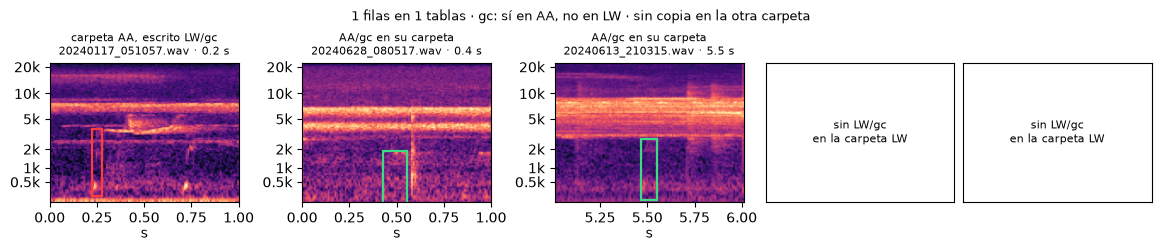

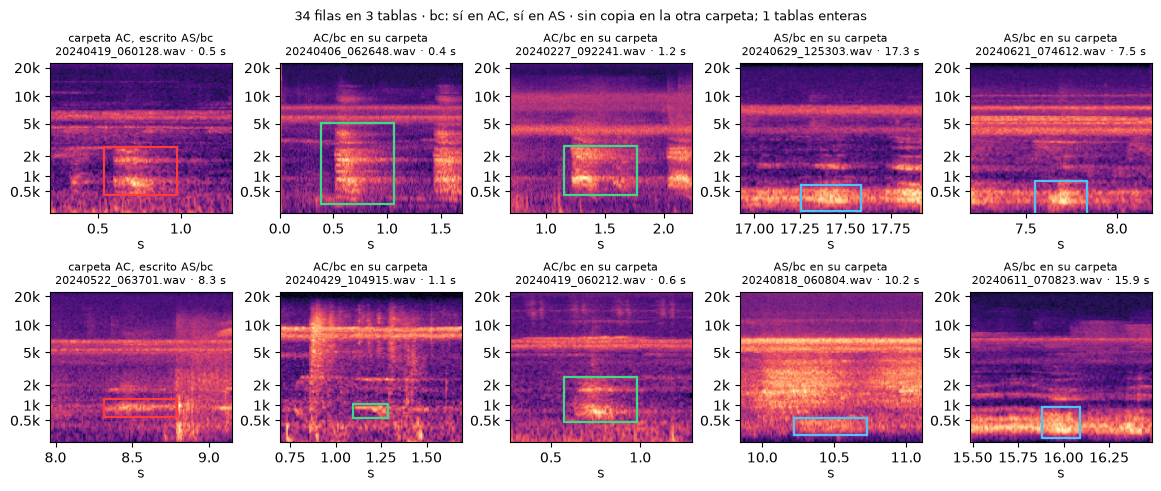

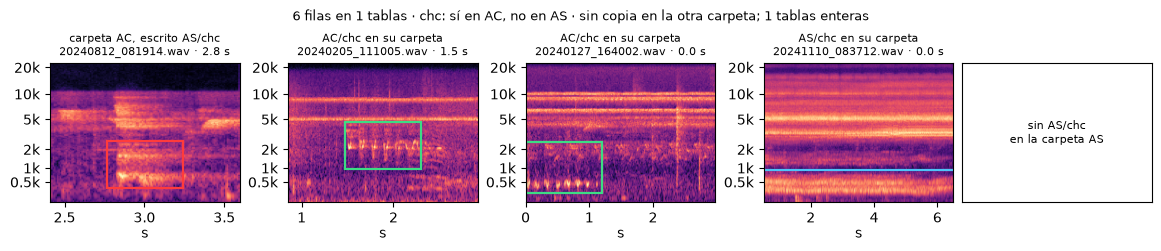

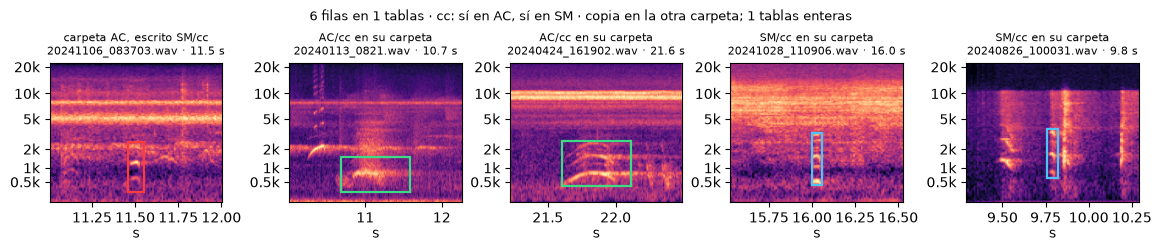

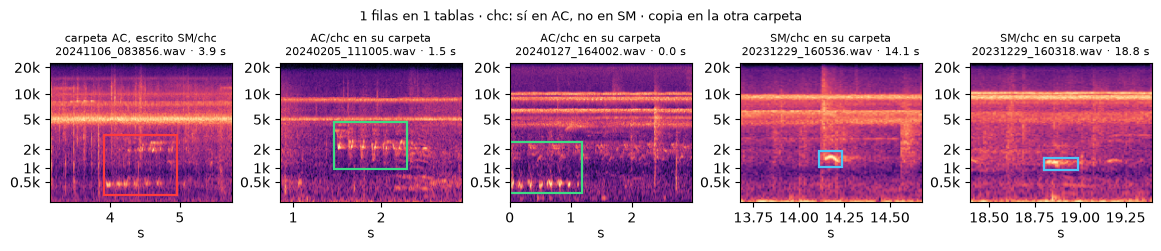

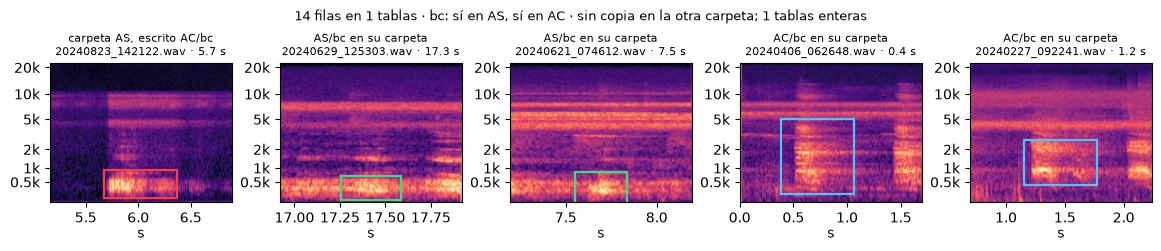

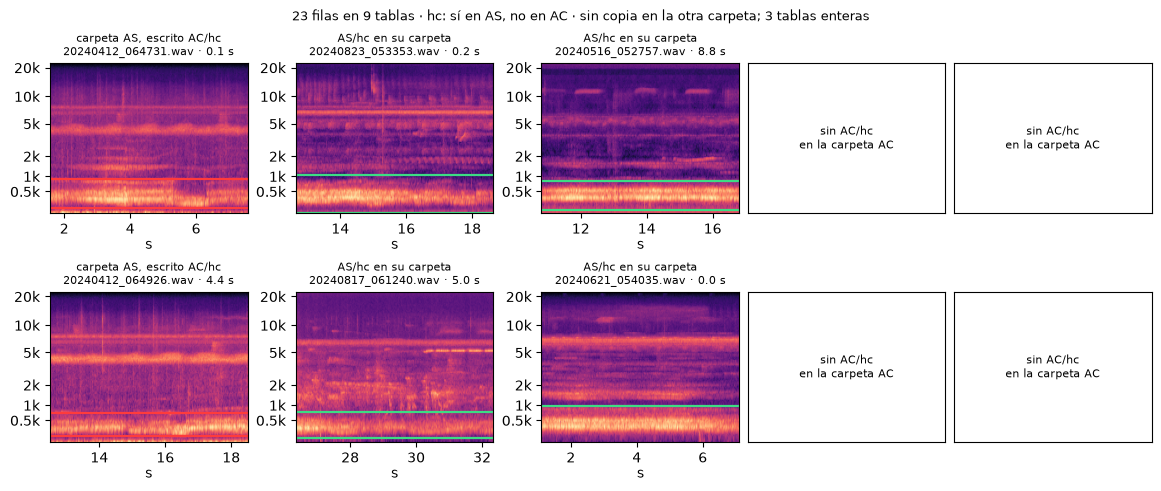

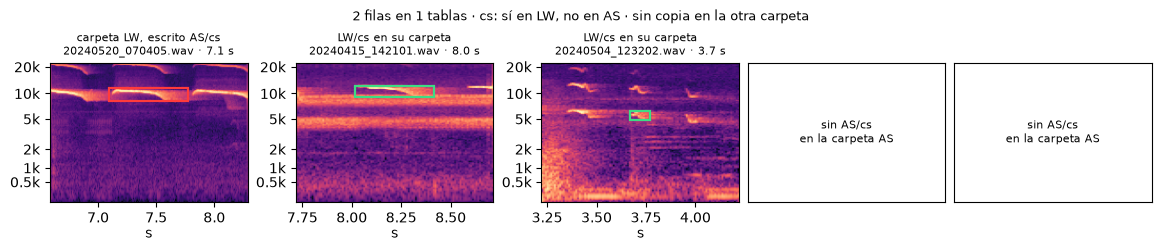

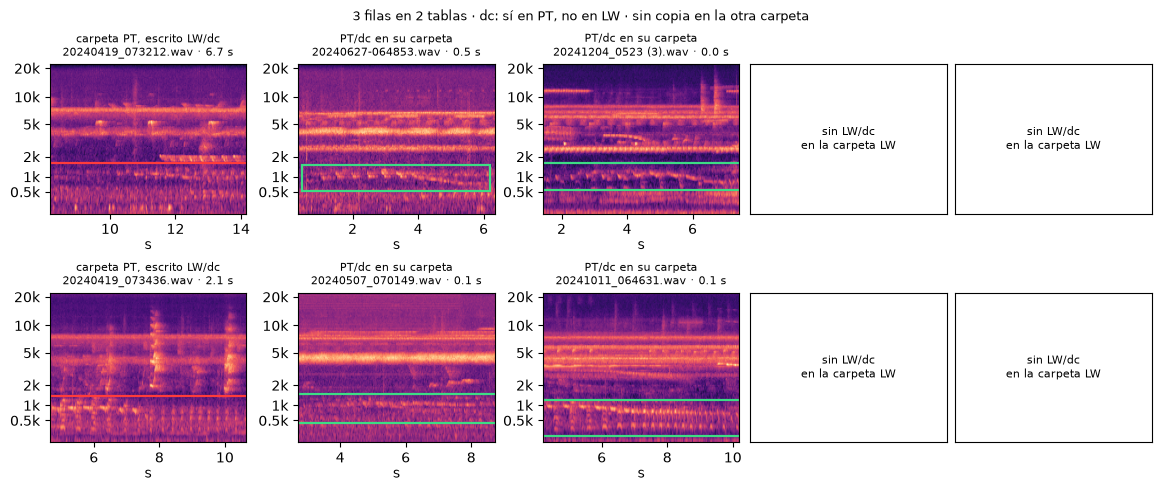

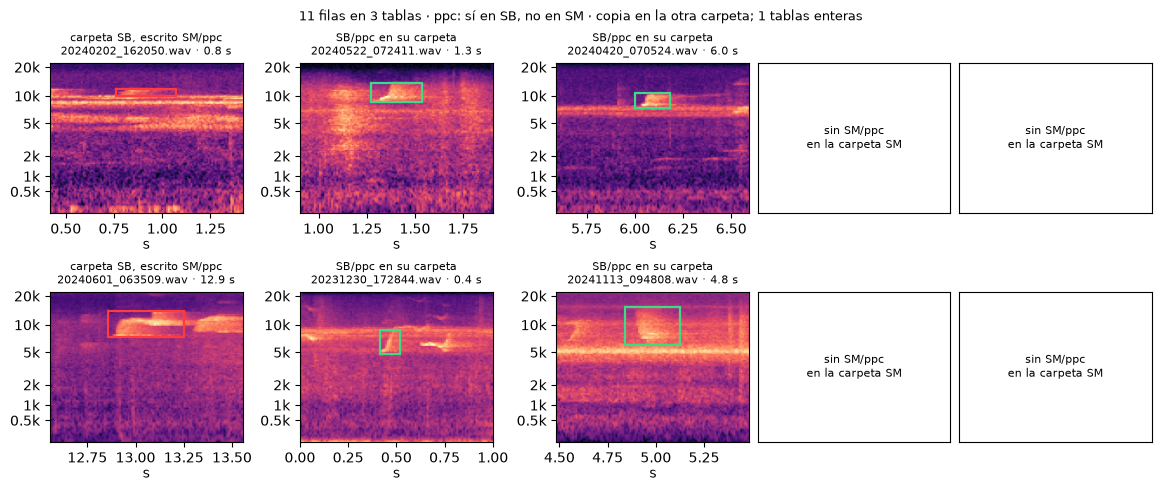

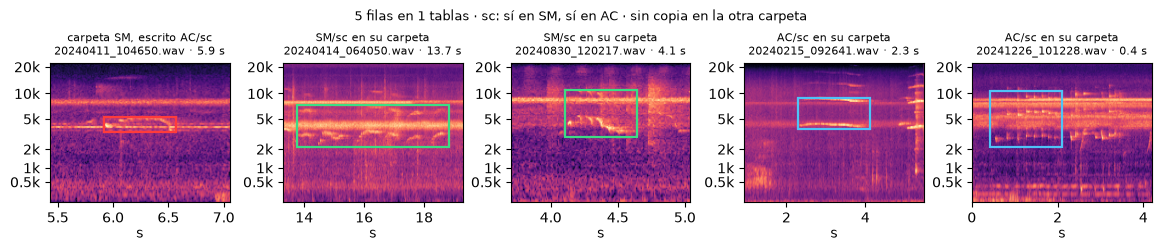

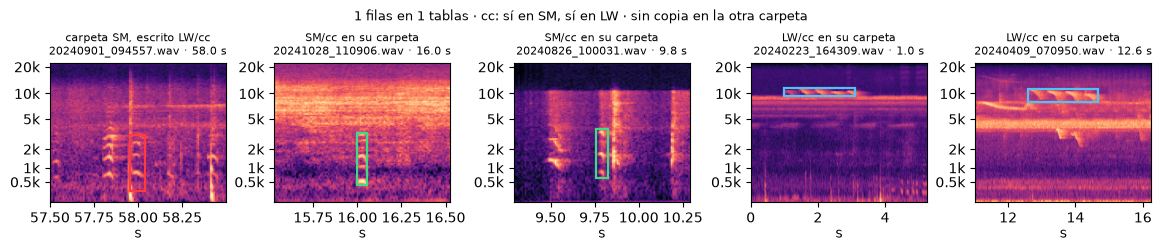

In [7]:
to_mel = mel_spectrogram()
frames_per_s = P.n_frames / P.clip_len_s
TICKS_HZ = np.array([500.0, 1000.0, 2000.0, 5000.0, 10000.0, 20000.0])
EVENTS_PER_GROUP, REFERENCES = 2, 2
concordant = raw.loc[(raw["written"] == "") | (raw["written"] == raw["folder"])]


def load_span(audio: str, start_s: float, span_s: float) -> torch.Tensor | None:
    try:
        info = soundfile.info(audio)
        frames, _ = soundfile.read(
            audio,
            start=int(start_s * info.samplerate),
            frames=int(span_s * info.samplerate),
            dtype="float32",
            always_2d=True,
        )
    except (soundfile.LibsndfileError, RuntimeError):
        return None
    waveform = torch.from_numpy(frames.mean(axis=1))
    if info.samplerate != P.target_sr:
        waveform = torchaudio.functional.resample(waveform, info.samplerate, P.target_sr)
    return waveform


def draw_event(ax: Axes, box: pd.Series, color: str, title: str) -> None:
    duration = float(box["end_time_s"] - box["begin_time_s"])
    span = float(np.clip(2.5 * duration, 1.0, 6.0))
    start = max(float(box["begin_time_s"]) - (span - duration) / 2, 0.0)
    waveform = load_span(box["audio"], start, span)
    ax.set_title(title, fontsize=8)
    ax.grid(False)
    if waveform is None:
        ax.text(0.5, 0.5, "audio ilegible", ha="center", va="center", transform=ax.transAxes)
        ax.set(xticks=[], yticks=[])
        return
    mel = mel_to_db(to_mel(waveform))
    ax.imshow(
        mel.numpy(), origin="lower", aspect="auto", cmap="magma", extent=(start, start + span, 0, 1)
    )
    y0, y1 = hz_to_y(np.array([box["low_freq_hz"], box["high_freq_hz"]], dtype=float), P)
    ax.add_patch(
        Rectangle(
            (box["begin_time_s"], y0), duration, y1 - y0, fill=False, edgecolor=color, linewidth=1.6
        )
    )
    ax.set_yticks(hz_to_y(TICKS_HZ, P).tolist(), [f"{f / 1000:g}k" for f in TICKS_HZ])
    ax.set_xlabel("s", labelpad=1)


def references(species: str, call: str, exclude_audio: str, n: int, seed: int) -> pd.DataFrame:
    pool = concordant.loc[
        (concordant["folder"] == species)
        & (concordant["call"] == call)
        & (concordant["audio"] != exclude_audio)
    ]
    return (
        pool.drop_duplicates("audio").sample(n=min(n, len(pool)), random_state=seed)
        if len(pool)
        else pool
    )


groups = discordant.loc[discordant["valid_code"]].groupby(["folder", "written", "call"])
for (folder, written, call), rows in groups:
    events = rows.drop_duplicates("audio").head(EVENTS_PER_GROUP)
    columns = 1 + 2 * REFERENCES
    fig, axes = plt.subplots(
        len(events),
        columns,
        figsize=(2.3 * columns, 2.4 * len(events)),
        squeeze=False,
        constrained_layout=True,
    )
    for seed, (row_axes, (_, event)) in enumerate(zip(axes, events.iterrows(), strict=True)):
        draw_event(
            row_axes[0],
            event,
            "#ff3b3b",
            f"carpeta {folder}, escrito {written}/{call}\n{Path(event['audio']).name} · {event['begin_time_s']:.1f} s",
        )
        panels = [(folder, "#3ddc84"), (written, "#4fc3f7")]
        for k, (species, color) in enumerate(panels):
            refs = references(species, call, str(event["audio"]), REFERENCES, seed)
            for j in range(REFERENCES):
                ax = row_axes[1 + k * REFERENCES + j]
                if j < len(refs):
                    ref = refs.iloc[j]
                    draw_event(
                        ax,
                        ref,
                        color,
                        f"{species}/{call} en su carpeta\n{Path(ref['audio']).name} · {ref['begin_time_s']:.1f} s",
                    )
                else:
                    ax.text(
                        0.5,
                        0.5,
                        f"sin {species}/{call}\nen la carpeta {species}",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                        fontsize=8,
                    )
                    ax.set(xticks=[], yticks=[])
                    ax.grid(False)
    note = (
        "copia en la otra carpeta"
        if rows["copy_in_written_folder"].any()
        else "sin copia en la otra carpeta"
    )
    if rows["whole_table"].any():
        note += f"; {int(rows.drop_duplicates('table')['whole_table'].sum())} tablas enteras"
    vocab = f"{call}: {'sí' if rows['call_in_folder'].iloc[0] else 'no'} en {folder}, {'sí' if rows['call_in_written'].iloc[0] else 'no'} en {written}"
    fig.suptitle(
        f"{len(rows)} filas en {rows['table'].nunique()} tablas · {vocab} · {note}", fontsize=9
    )
    plt.show()

## 6. Resumen por causa probable

Regla mecánica, para ordenar la revisión con el equipo (la decisión final es de ellos):

- **tipeo**: el tipo de llamada existe en el vocabulario de la carpeta y no en el de la especie
  escrita, o la especie escrita no es un código válido;
- **copia**: la grabación está copiada en la carpeta de la especie escrita y allí aparece la misma
  caja;
- **otra especie**: el tipo de llamada existe sólo en el vocabulario de la especie escrita;
- **tabla entera**: toda la tabla (3 filas o más) lleva la otra especie y el tipo existe en ambos
  vocabularios: la grabación se anotó como si fuera de la especie escrita;
- **ambiguo**: el tipo existe en ambos vocabularios, sin copia y en una tabla mixta; se decide
  con la figura.

In [8]:
def probable_cause(box: pd.Series) -> str:
    if not box["valid_code"] or (box["call_in_folder"] and not box["call_in_written"]):
        return "tipeo"
    if box["same_box_in_copy"]:
        return "copia"
    if box["call_in_written"] and not box["call_in_folder"]:
        return "otra especie"
    return "tabla entera" if box["whole_table"] else "ambiguo"


discordant["causa_probable"] = [probable_cause(box) for _, box in discordant.iterrows()]
causes = (
    discordant.groupby(["folder", "written", "call", "causa_probable"])
    .size()
    .rename("filas")
    .reset_index()
)
print(discordant["causa_probable"].value_counts().to_string())
causes

causa_probable
tipeo           69
tabla entera    45
ambiguo          9
copia            6


,folder,written,call,causa_probable,filas
0,AA,AN,hc,tipeo,1
1,AA,AN,hm,tipeo,1
2,AA,LW,gc,tipeo,1
3,AA,},gc,tipeo,1
4,AC,AS,bc,ambiguo,3
5,AC,AS,bc,tabla entera,31
6,AC,AS,chc,tipeo,6
7,AC,SM,cc,copia,6
8,AC,SM,chc,tipeo,1
9,AS,AC,bc,tabla entera,14
